In [1]:
import time
import numpy as np
import pandas as pd
import random as rd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import basinhopping, minimize
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid", {'axes.grid' : False})
plt.rcParams['font.family'] = ['Microsoft YaHei','Arial']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 定义目标函数 
eps = 1e-7

def objective(x):
    p1, p2, p3 = x
    if c <= p1 and p1 <= u1:
        r1 = (p1-c)*(u1-p1)/(1-p1)
    else:
        r1 = 0
    if c <= p2 and p2 <= u2:
        r2 = (p2-c)*(u2-p2)/(1-p2)
    else:
        r2 = 0
    if c <= p3 and p3 <= u3:
        r3 = (p3-c)*(u3-p3)/(1-p3)
    else:
        r3 = 0
    R = r1 + r2 + r3
    return -R - eps * (p3 - p2)  # 最大化加 -  // 

def constraint1(x):
    # p1 >= c
    return x[0] - c

def constraint2(x):
    # p2 >= p1
    return x[1] - x[0]

def constraint3(x):
    # p3 >= p2
    return x[2] - x[1]

def constraint4(x):
    # 1 >= p3 
    return 1 - x[2]

def constraint5(x):
    # delta >= p3 - p1
    return delta - (x[2] - x[0])

constraints = [
    {'type': 'ineq', 'fun': constraint1},  # 默认>=0
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3},
    {'type': 'ineq', 'fun': constraint4},
    {'type': 'ineq', 'fun': constraint5}
]

# 1. 三类客户

第1次试验
最优p1: 0.452277
最优p2: 0.510102
最优p3: 0.653590
最大利润: 0.131939


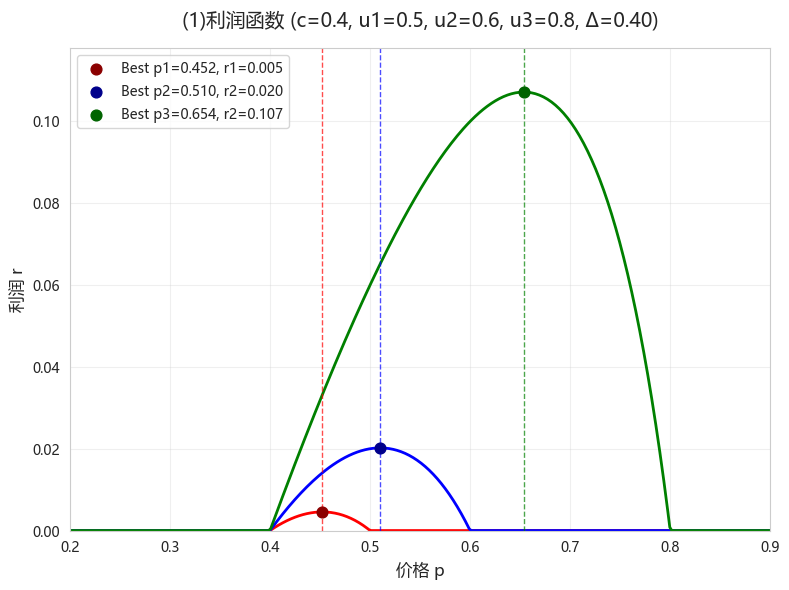

In [3]:
c =  0.4
u1 = 0.5
u2 = 0.6
u3 = 0.8
delta = u3 - c

for i in range(1):
#     c = rd.randint(0, 6)
#     u1 = rd.randint(c+1, 7)
#     u2 = rd.randint(u1+1, 8)
#     u3 = rd.randint(u2+1, 9) * 0.1
#     c *= 0.1
#     u1 *= 0.1
#     u2 *= 0.1
#     if u2 > 1- (1-u1)**2/(1-c):
#         continue
#     delta = (u3 - c) * rd.random()

    bounds = [(c, u3), (c, u3), (c, u3)]
    initial_guess = np.array([(c+u1)/2, (c+u2)/2, (c+u3)/2])

    result = minimize(objective, initial_guess, 
                 bounds=bounds, 
                 constraints=constraints, 
                 method='SLSQP',
                 tol=1e-12,               # 收敛容忍度
                 options={'ftol': 1e-12,  # 函数值变化的容忍度
                          'eps': 1e-8,    # 有限差分步长
                          'maxiter': 1000, # 最大迭代次数
                          'disp': False}   # 显示优化过程信息
            )

    optimal_p1, optimal_p2, optimal_p3 = result.x
    max_profit = -result.fun

    print(f'第{i+1}次试验')
    print(f"最优p1: {optimal_p1:.6f}")
    print(f"最优p2: {optimal_p2:.6f}")
    print(f"最优p3: {optimal_p3:.6f}")
    print(f"最大利润: {max_profit:.6f}")
    
    plt.figure(figsize=(8, 6))
    p_values = np.linspace(0, 1, 500)  # 生成数据点
    
    r1_values = []
    r2_values = []
    r3_values = []
    for p in p_values:
        if c <= p <= u1:
            r1 = (p-c)*(u1-p)/(1-p)
        else:
            r1 = 0
        if c <= p <= u2:
            r2 = (p-c)*(u2-p)/(1-p)
        else:
            r2 = 0
        if c <= p <= u3:
            r3 = (p-c)*(u3-p)/(1-p)
        else:
            r3 = 0
        r1_values.append(r1)
        r2_values.append(r2)
        r3_values.append(r3)

    plt.plot(p_values, r1_values, linewidth=2, color='red')  #, label=f'$r_1(p) = (p-{c:.1f})({u1:.1f}-p)/(1-p)$'
    plt.plot(p_values, r2_values, linewidth=2, color='blue')  #, label=f'$r_2(p) = (p-{c:.1f})({u2:.1f}-p)/(1-p)$'
    plt.plot(p_values, r3_values, linewidth=2, color='green')  #, label=f'$r_3(p) = (p-{c:.1f})({u3:.1f}-p)/(1-p)$'
    
    # 计算最优点的函数值
    if c <= optimal_p1 <= u1:
        optimal_r1 = (optimal_p1-c)*(u1-optimal_p1)/(1-optimal_p1)
    else:
        optimal_r1 = 0
    if c <= optimal_p2 <= u2:
        optimal_r2 = (optimal_p2-c)*(u2-optimal_p2)/(1-optimal_p2)
    else:
        optimal_r2 = 0
    if c <= optimal_p3 <= u3:
        optimal_r3 = (optimal_p3-c)*(u3-optimal_p3)/(1-optimal_p3)
    else:
        optimal_r3 = 0
    
    # 标记最优点
    plt.scatter(optimal_p1, optimal_r1, s=60, color='darkred', marker='o', 
               label=f'Best p1={optimal_p1:.3f}, r1={optimal_r1:.3f}', zorder=5)
    plt.scatter(optimal_p2, optimal_r2, s=60, color='darkblue', marker='o', 
               label=f'Best p2={optimal_p2:.3f}, r2={optimal_r2:.3f}', zorder=5)
    plt.scatter(optimal_p3, optimal_r3, s=60, color='darkgreen', marker='o', 
               label=f'Best p3={optimal_p3:.3f}, r2={optimal_r3:.3f}', zorder=5)
    
    # 添加垂直线标记最优价格
    plt.axvline(x=optimal_p1, color='red', linestyle='--', alpha=0.7, linewidth=1)
    plt.axvline(x=optimal_p2, color='blue', linestyle='--', alpha=0.7, linewidth=1)
    plt.axvline(x=optimal_p3, color='green', linestyle='--', alpha=0.7, linewidth=1)

    # 设置图形属性
    plt.xlabel('价格 p', fontsize=12)
    plt.ylabel('利润 r', fontsize=12)
    plt.title(f'({i+1})利润函数 (c={c}, u1={u1}, u2={u2}, u3={u3}, Δ={delta:.2f})', fontsize=14, pad=16)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # 设置坐标轴范围
    plt.xlim(0.5*c, (u3+1)/2)
    plt.ylim(0, max(max(r1_values), max(r3_values)) * 1.1)
      
    plt.tight_layout()
    plt.show()

# 2. 随Δ变化

In [4]:
Profits = []
opt_p1 = []
opt_p2 = []
opt_p3 = []

num = 300
deltas = np.linspace(start=0, stop=num/1000, num=num)

print(f'{num}次试验开始……')
start = time.time()
for i in range(num):
    delta = deltas[i]    #  delta = 0.5 * i / num + 0.001
    bounds = [(c, u3), (c, u3), (c, u3)]
    initial_guess = np.array([(c+u1)/2, (c+u2)/2, (c+u3)/2])

    result = basinhopping(objective, initial_guess, niter=100,
                     minimizer_kwargs={'method': 'SLSQP', 
                                     'bounds': bounds,
                                     'constraints': constraints,
                                     'options': {'ftol': 1e-8}}
            )
    
    optimal_p1, optimal_p2, optimal_p3 = result.x
    max_profit = -result.fun

    Profits.append(max_profit)
    opt_p1.append(optimal_p1)
    opt_p2.append(optimal_p2)
    opt_p3.append(optimal_p3)
    
total_time = time.time() - start
print(f'试验完毕, 用时{total_time:.2f}s')

300次试验开始……
试验完毕, 用时261.69s


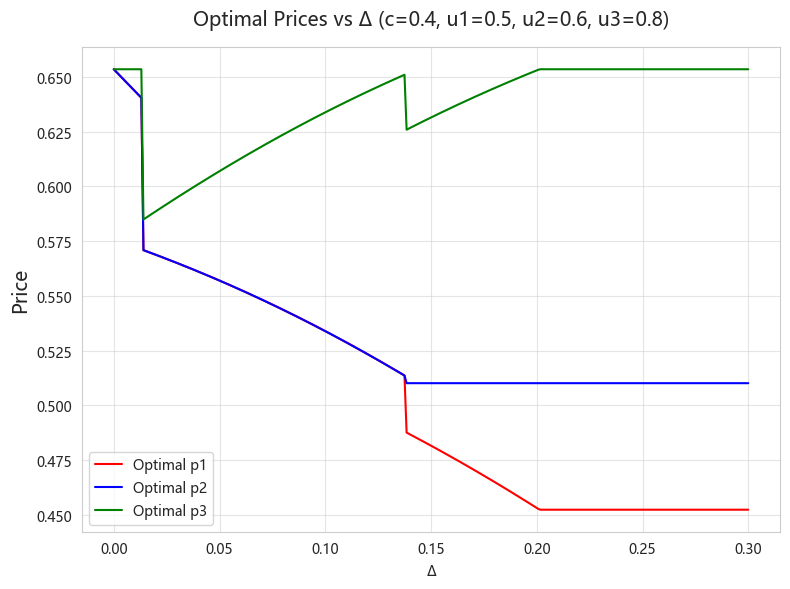

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(deltas, opt_p1, alpha=1, color="red", label='Optimal p1')
plt.plot(deltas, opt_p2, alpha=1, color="blue", label='Optimal p2')
plt.plot(deltas, opt_p3, alpha=1, color="green", label='Optimal p3')
plt.title(f"Optimal Prices vs Δ (c={c}, u1={u1}, u2={u2}, u3={u3})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Price", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

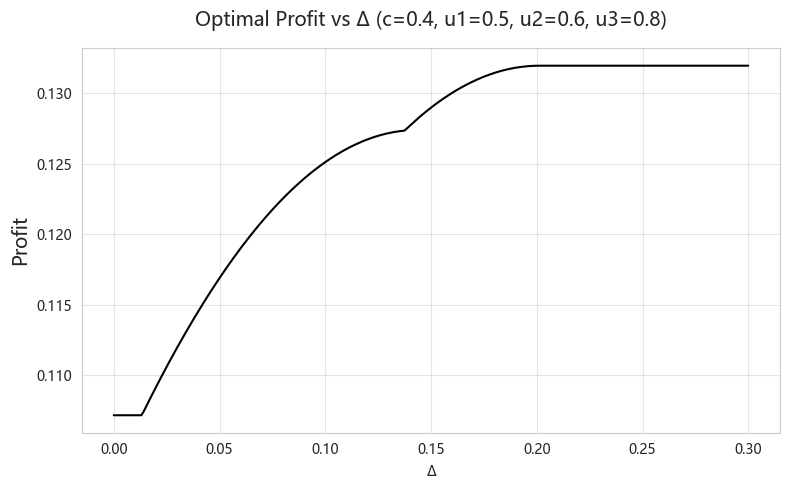

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Profits, alpha=1, color="black")
plt.title(f"Optimal Profit vs Δ (c={c}, u1={u1}, u2={u2}, u3={u3})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Profit", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
from math import sqrt
import random as rd

# c=0.2
# u1=0.5
# u2=0.9

# assumpt_1 = u1 - 1 + sqrt((1-c)*(2-u1-u2)/2)
# RT = (2 - 2*c - u1 + c*u1 - u2 + c*u2)
# assumpt_2 = sqrt(2) * (1 - c - RT/sqrt(2)) * (-2 + sqrt(2)*RT + u1 + u2) / RT  \
#          -(sqrt(1-c)-sqrt(1-u2))**2

# print("c:",c,", u1:",u1,", u2:",u2)
# print(assumpt_1, assumpt_2)
# print(1-(1-u1)**2/(1-c) - u2)

In [8]:
# plt.figure(figsize=(8, 6))
# plt.scatter(range(len(K_gap)), K_gap, alpha=1, s=10, color="blue")  # markersize=8 // s=8
# plt.axhline(y=0, color="yellow", linestyle="--", linewidth=3)
# plt.title("Slope Gap Plot", fontsize=16, pad=16)
# plt.xlabel("")
# plt.ylabel("Gap", fontsize=14)
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()